In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statistics as stats
import scipy.stats as stats

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/HOMEWORK_AB_TESTING/ab_app_subscription.csv')
df

,period,cohort_date,variant,user_id,country,platform,traffic_source,device_model,age,sessions_7d,time_to_first_action_min,trial_start,paid_subscriber,revenue_30d
0,during,2025-07-05,B,APP201334,ID,android,organic,low_end,54,4,6.1,0,0,444.616527
1,during,2025-07-04,A,APP201596,ID,android,organic,low_end,24,2,6.5,0,0,424.835708
2,during,2025-07-06,A,APP200545,TH,android,organic,mid_range,41,4,7.3,0,0,393.086785
3,during,2025-07-07,B,APP203155,MY,android,organic,mid_range,40,1,2.3,0,0,502.190971
4,during,2025-07-04,A,APP202354,ID,android,paid,mid_range,49,6,2.4,1,0,432.384427
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
500,during,2025-07-06,A,APP203295,ID,android,organic,low_end,21,3,6.1,1,1,451.623263
501,during,2025-07-10,B,APP203577,TH,android,organic,flagship,22,8,3.8,1,0,447.467872
502,during,2025-07-09,A,APP202962,ID,android,social,mid_range,34,5,6.6,1,1,324.031502
503,during,2025-07-11,A,APP207633,ID,ios,paid,low_end,48,4,3.4,0,0,375.788296


In [ ]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 505 entries, 0 to 504
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   period                    505 non-null    object 
 1   cohort_date               505 non-null    object 
 2   variant                   505 non-null    object 
 3   user_id                   505 non-null    object 
 4   country                   505 non-null    object 
 5   platform                  505 non-null    object 
 6   traffic_source            505 non-null    object 
 7   device_model              505 non-null    object 
 8   age                       505 non-null    int64  
 9   sessions_7d               505 non-null    int64  
 10  time_to_first_action_min  505 non-null    float64
 11  trial_start               505 non-null    int64  
 12  paid_subscriber           505 non-null    int64  
 13  revenue_30d               505 non-null    float64
dtypes: float64

,period,cohort_date,variant,user_id,country,platform,traffic_source,device_model,age,sessions_7d,time_to_first_action_min,trial_start,paid_subscriber,revenue_30d
0,during,2025-07-05,B,APP201334,ID,android,organic,low_end,54,4,6.1,0,0,444.616527
1,during,2025-07-04,A,APP201596,ID,android,organic,low_end,24,2,6.5,0,0,424.835708
2,during,2025-07-06,A,APP200545,TH,android,organic,mid_range,41,4,7.3,0,0,393.086785
3,during,2025-07-07,B,APP203155,MY,android,organic,mid_range,40,1,2.3,0,0,502.190971
4,during,2025-07-04,A,APP202354,ID,android,paid,mid_range,49,6,2.4,1,0,432.384427


In [ ]:
df.describe()

,age,sessions_7d,time_to_first_action_min,trial_start,paid_subscriber,revenue_30d
count,505.000000,505.000000,505.000000,505.000000,505.000000,505.000000
mean,35.374257,5.229703,5.652871,0.174257,0.027723,439.759243
std,10.922914,2.428074,3.970526,0.379707,0.164340,63.535302
min,17.000000,0.000000,0.200000,0.000000,0.000000,269.012745
25%,27.000000,3.000000,2.600000,0.000000,0.000000,396.277704
50%,36.000000,5.000000,4.800000,0.000000,0.000000,438.550249
75%,45.000000,7.000000,7.600000,0.000000,0.000000,483.704739
max,54.000000,14.000000,29.000000,1.000000,1.000000,633.944040


In [ ]:
df.describe(include='object')

,period,cohort_date,variant,user_id,country,platform,traffic_source,device_model
count,505,505,505,505,505,505,505,505
unique,1,14,2,505,6,2,4,3
top,during,2025-07-06,A,APP203386,ID,android,organic,mid_range
freq,505,56,257,1,244,361,245,275


In [ ]:
variant_a = df[df['variant'] == 'A']['revenue_30d'].values
variant_b = df[df['variant'] == 'B']['revenue_30d'].values

variant_a

array([424.83570765, 393.08678494, 432.38442691, 476.15149282,
       388.29233126, 388.29315215, 478.96064078, 438.37173646,
       376.5262807 , 427.12800218, 376.82911536, 376.71351232,
       412.09811358, 304.33598777, 313.75410837, 371.88562354,
       349.35844398, 415.71236663, 354.59879622, 329.38481493,
       473.28243845, 388.71118498, 403.37641023, 328.76259069,
       372.78086377, 405.54612949, 342.45032113, 418.78490092,
       369.9680655 , 385.41531251, 369.91466939, 492.61390923,
       399.32513876, 347.11445355, 441.12724561, 338.9578175 ,
       410.44317975, 302.01649381, 333.59069756, 409.84306179,
       436.923329  , 408.56841406, 394.21758588, 384.94481522,
       326.07390048, 364.00778958, 376.96806145, 452.85611131,
       417.18091448, 311.84799223, 416.20419847, 380.74588598,
       366.15389998, 430.58381444, 451.54997612, 446.56400596,
       358.03912384, 384.53938121, 416.56317157, 448.77725636,
       376.04128811, 390.71705117, 344.6832513 , 340.18

In [ ]:
variant_b

array([444.61652672, 502.19097141, 518.73170267, 433.65347642,
       477.0237322 , 317.936633  , 428.78061793, 467.37159243,
       417.6108409 , 561.6205652 , 408.4929311 , 457.99777567,
       486.53702886, 552.06366445, 408.20689244, 538.15818761,
       480.51165305, 430.92456745, 503.10517371, 489.95298478,
       449.98915614, 483.49010425, 460.73432016, 485.67586726,
       513.10653373, 559.30084081, 418.10922506, 586.65166873,
       382.39561002, 472.41074525, 509.41586032, 494.04959339,
       448.86502401, 469.59388748, 455.34995327, 450.53176215,
       522.48010485, 497.8507743 , 445.35452024, 524.97999377,
       495.36497604, 520.64310594, 511.4814421 , 438.55024945,
       451.99094799, 517.36468026, 510.51851327, 478.9549203 ,
       485.86636917, 543.88324479, 450.42143056, 507.35486906,
       469.89036738, 469.11593984, 534.9388426 , 521.27081745,
       520.6754818 , 545.27394036, 481.05019208, 514.09764856,
       464.48666217, 496.20831762, 473.49284728, 484.84

In [ ]:
#nomality check with shapiro wilk test
import scipy.stats as stats

stat_A, p_A = stats.shapiro(variant_a)
stat_B, p_B = stats.shapiro(variant_b)

print(f"Shapiro-Wilk Test for Variant A: Statistics={stat_A:.3f}, p-value={p_A:.3f}")
print(f"Shapiro-Wilk Test for Variant B: Statistics={stat_B:.3f}, p-value={p_B:.3f}")

Shapiro-Wilk Test for Variant A: Statistics=0.992, p-value=0.167
Shapiro-Wilk Test for Variant B: Statistics=0.997, p-value=0.880


#Kesimpulan
1. Untuk Variant A, p-value = 0.167 > 0.05 → data berdistribusi normal
2. Untuk Variant B, p-value = 0.880 > 0.05 → data berdistribusi normal

In [ ]:
#uji homogenitas
stat, p = stats.levene(
    df[df['variant']=='A']['revenue_30d'],
    df[df['variant']=='B']['revenue_30d']
)
print(f"Levene’s test p-value: {p:.3f}")


Levene’s test p-value: 0.751


#Kesimpulan
uji homogenitas dilakukan karena hasil uji normalitas data hasilnya data terdistrinusi normal

Karena p-value = 0.751 > 0.05, maka:

Gagal menolak H₀ — artinya varians revenue_30 pada Variant A dan Variant B adalah homogen (sama).

In [ ]:
# uji t-test
from scipy.stats import ttest_ind

revenue_a = df[df['variant'] == 'A']['revenue_30d']
revenue_b = df[df['variant'] == 'B']['revenue_30d']

stat, p_value = ttest_ind(revenue_a, revenue_b, equal_var=True)

print(f"Independent t-test Statistic: {stat}")
print(f"Independent t-test P-value: {p_value}")

p = 0.05
if p_value > 0.05:
    print("Tidak terdapat perbedaan signifikan pada rata-rata revenue antara Variant A dan Variant B (gagal menolak H0, α = 0.05)")
else:
    print("Terdapat perbedaan signifikan pada rata-rata revenue antara Variant A dan Variant B (menolak H0, α = 0.05)")

Independent t-test Statistic: -18.342420905397265
Independent t-test P-value: 6.435448411416861e-58
Terdapat perbedaan signifikan pada rata-rata revenue antara Variant A dan Variant B (menolak H0, α = 0.05)


#Kesimpulan
uji t-test dilakukan karena hasil uji homogenitasnya adalah varian sama, maka dilakukan uji t-test
1. Berdasarkan hasil uji-t (t = -18.34, p < 0.05), terdapat perbedaan yang signifikan antara rata-rata revenue_30 Variant A dan Variant B.
2. Dengan demikian, varian baru (B) memiliki dampak berbeda terhadap pendapatan dibandingkan varian lama (A).

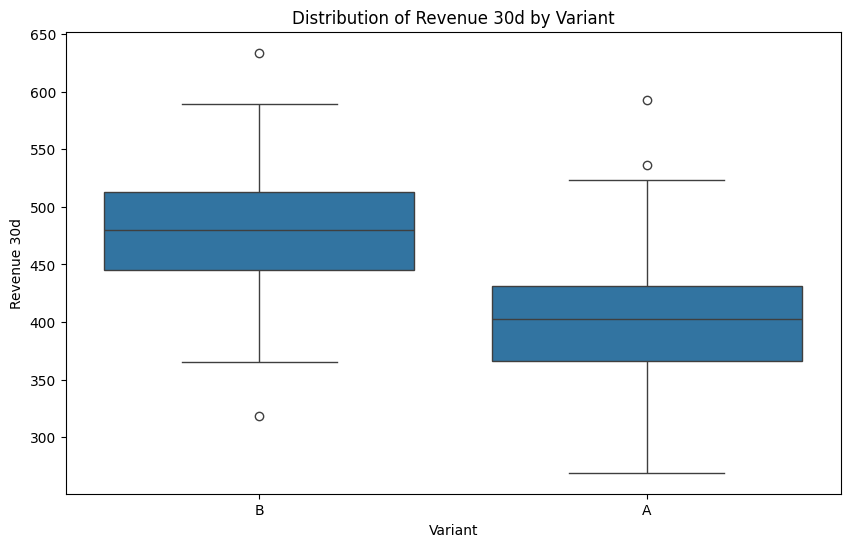

In [ ]:
#visualisasi data varian a dan b
plt.figure(figsize=(10, 6))
df_filtered = df[df['variant'].isin(['A', 'B'])]
sns.boxplot(x='variant', y='revenue_30d', data=df_filtered)
plt.title('Distribution of Revenue 30d by Variant')
plt.xlabel('Variant')
plt.ylabel('Revenue 30d')
plt.show()

#Interpretasi
Pengguna di Variant B secara konsisten menghasilkan revenue 30 hari lebih tinggi daripada pengguna di Variant A, dan perbedaan ini signifikan.

In [ ]:
#menghitung mean varian a dan b
mean_variant_a = np.mean(variant_a)
mean_variant_b = np.mean(variant_b)

print(f"Mean for Variant A: {mean_variant_a:.2f}")
print(f"Mean for Variant B: {mean_variant_b:.2f}")

Mean for Variant A: 400.29
Mean for Variant B: 480.67


#kesimpulan
Variant B tampak lebih unggul dari Variant A dalam menghasilkan revenue rata-rata.

In [ ]:
#menghitung median varian a dan b
median_variant_a = np.median(variant_a)
median_variant_b = np.median(variant_b)

print(f"Median for Variant A: {median_variant_a:.2f}")
print(f"Median for Variant B: {median_variant_b:.2f}")

Median for Variant A: 403.01
Median for Variant B: 479.93


#Kesimpulan
Variant B unggul dibanding Variant A,  menandakan tren peningkatan revenue yang konsisten di kelompok B.

In [ ]:
mean_A = df[df['variant'] == 'A']['revenue_30d'].mean()
mean_B = df[df['variant'] == 'B']['revenue_30d'].mean()
std_A = df[df['variant'] == 'A']['revenue_30d'].std()
std_B = df[df['variant'] == 'B']['revenue_30d'].std()

# Cohen's d
cohen_d = (mean_B - mean_A) / np.sqrt((std_A**2 + std_B**2) / 2)
print(f"Cohen's d: {cohen_d:.3f}")

Cohen's d: 1.632


#Kesimpulan
Pengguna di Variant B secara konsisten memiliki revenue yang jauh lebih tinggi dibandingkan pengguna di Variant A, dan efek dari perlakuan (misalnya desain, fitur, atau promo baru) di Variant B berdampak besar terhadap peningkatan revenue.